# Aula 8 – Análise de Sentimentos - Exemplo 2

**Objetivo:** manter a explicação passo a passo, mas entregar um **resultado melhor**.

Melhorias:
- base maior e balanceada (ainda didática)
- split treino/teste
- TF-IDF com bigramas
- Regressão Logística
- métricas + matriz de confusão

## 1. Preparação

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 2. Mini-corpus rotulado (mais informativo)

In [3]:
textos = [
    # positivos
    "O produto é ótimo",
    "O produto é excelente",
    "Gostei muito do produto",
    "A experiência foi excelente",
    "Atendimento rápido e ótimo",
    "Serviço muito bom",
    "Entrega foi rápida e ótima",
    "Estou satisfeito com o atendimento",
    "O sistema funciona muito bem",
    "Valeu a pena comprar",

    # negativos
    "O produto é ruim",
    "O produto é péssimo",
    "Não gostei do produto",
    "A experiência foi ruim",
    "Atendimento lento e péssimo",
    "Serviço muito ruim",
    "A entrega foi atrasada e ruim",
    "Estou insatisfeito com o atendimento",
    "O sistema falha e é ruim",
    "Não valeu a pena comprar",
]
# rótulos
sentimentos = np.array([1]*10 + [0]*10)
print("N:", len(textos), "| positivo:", int(sentimentos.sum()), "| negativo:", int((1-sentimentos).sum()))

N: 20 | positivo: 10 | negativo: 10


## 3. Split treino/teste

Ele divide o conjunto de dados rotulados em duas partes distintas:

- conjunto de treino → usado para aprender o modelo

- conjunto de teste → usado para avaliar o modelo em dados não vistos

Essa separação é essencial para responder à pergunta:

> *O modelo realmente aprendeu padrões gerais ou apenas memorizou os exemplos?*


In [4]:
from sklearn.model_selection import train_test_split

# Função responsável por particionar dados aleatoriamente, mantendo correspondência entre: textos e sentimentos
# test_size=0.30 - 30% dos dados vão para o conjunto de teste
# random_state=42 - usa a mesma sequência de números aleatórios
# stratify=sentimentos - divide os dados mantendo a proporção de sentimentos positivos e negativos
X_train_txt, X_test_txt, y_train, y_test = train_test_split(
    textos, sentimentos, test_size=0.30, random_state=42, stratify=sentimentos
)

print("Treino:", len(X_train_txt), "| Teste:", len(X_test_txt))

Treino: 14 | Teste: 6


## 4. Vetorização com TF-IDF e bigramas

No notebook "Exemplo 1", utilizamos a representação Bag-of-Words, aqui avançamos para uma representação **mais informativa**, baseada em **TF-IDF (Term Frequency–Inverse Document Frequency)**.

### O que é TF-IDF?

A ideia central do TF-IDF é atribuir pesos às palavras considerando dois fatores:

- **TF (Term Frequency)**  
  Mede o quão frequente uma palavra é dentro de um texto.

- **IDF (Inverse Document Frequency)**  
  Reduz o peso de palavras que aparecem em muitos textos do corpus, pois essas palavras tendem a ser menos discriminativas.

Em termos intuitivos:

> Palavras **raras e informativas** recebem mais peso do que palavras **muito comuns**.


### Por que usar TF-IDF em vez de Bag-of-Words?

O TF-IDF ajuda a mitigar problemas observados no notebook "Exemplo 1", como:
- palavras neutras (“produto”, “serviço”) influenciando excessivamente a decisão;
- sensibilidade exagerada a termos muito frequentes.

Essa representação costuma produzir **modelos mais estáveis e generalizáveis**.


### Uso de bigramas (`ngram_range=(1,2)`)

Além de palavras individuais (**unigramas**), estamos incluindo **bigramas**, isto é:
- sequências de **duas palavras consecutivas**.

Exemplos de bigramas relevantes:
- "não gostei"
- "muito bom"
- "vale a pena"

Isso permite ao modelo capturar **informação contextual mínima**, especialmente importante em Análise de Sentimentos, onde:
- a combinação de palavras pode inverter o significado;
- expressões compostas carregam mais informação do que palavras isoladas.


### Separação entre treino e teste

- O método `fit_transform` é aplicado **apenas aos textos de treino**, para aprender o vocabulário e os pesos.
- O método `transform` é aplicado aos textos de teste, garantindo que **nenhuma informação do teste vaze para o treino**.

Essa separação é essencial para uma avaliação justa do modelo.

### Dimensionalidade do espaço vetorial

Por fim, exibimos o número de *features* (palavras e bigramas) aprendidas pelo vetor TF-IDF.
Esse número indica a **dimensão do espaço vetorial** no qual os textos estão sendo representados.


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1,2))
X_train = vectorizer.fit_transform(X_train_txt)
X_test = vectorizer.transform(X_test_txt)

# Cada feature é uma palavra ou bigrama aprendida pelo modelo
feature_names = vectorizer.get_feature_names_out()

print("Nº total de features:", len(feature_names))

Nº total de features: 53


In [9]:
# Calcula o TF-IDF médio de cada feature no conjunto de treino
tfidf_medio = X_train.mean(axis=0).A1  # converte matriz esparsa para array 1D

# Índices das features mais relevantes
top_k = 20
indices_top = np.argsort(tfidf_medio)[::-1][:top_k]

print(f"\nExibindo as {top_k} principais features por peso médio:")
for i in indices_top:
    print(f"{feature_names[i]:25s} -> TF-IDF médio = {tfidf_medio[i]:.4f}")


Exibindo as 20 principais features por peso médio:
produto                   -> TF-IDF médio = 0.1416
ruim                      -> TF-IDF médio = 0.0940
muito                     -> TF-IDF médio = 0.0777
atendimento               -> TF-IDF médio = 0.0719
ótimo                     -> TF-IDF médio = 0.0718
excelente                 -> TF-IDF médio = 0.0705
serviço muito             -> TF-IDF médio = 0.0628
serviço                   -> TF-IDF médio = 0.0628
sistema                   -> TF-IDF médio = 0.0542
com                       -> TF-IDF médio = 0.0512
estou                     -> TF-IDF médio = 0.0512
com atendimento           -> TF-IDF médio = 0.0512
produto ruim              -> TF-IDF médio = 0.0505
não                       -> TF-IDF médio = 0.0487
produto ótimo             -> TF-IDF médio = 0.0487
produto excelente         -> TF-IDF médio = 0.0487
produto péssimo           -> TF-IDF médio = 0.0461
péssimo                   -> TF-IDF médio = 0.0461
muito ruim                -> T

## 5. Modelo de Classificação: Regressão Logística

No notebook "Exemplo 1", utilizamos o Naive Bayes Multinomial, um classificador probabilístico simples, que:
- estima probabilidades de palavras dado cada classe;
- assume independência condicional entre as palavras;
- é eficiente e interpretável, mas sensível a dados pequenos e sinais conflitantes.

Nesta etapa, avançamos para um modelo **mais robusto e amplamente utilizado em PLN**: a **Regressão Logística**.


### O que é a Regressão Logística?

Apesar do nome, a Regressão Logística é um **classificador**, não um modelo de regressão tradicional. Ela aprende:

- uma **função linear** sobre as *features* do texto (TF-IDF);
- que é transformada em **probabilidade** por meio da função logística (sigmoide).

Em termos intuitivos:

> o modelo aprende **pesos** para cada palavra (ou bigrama) e combina essas evidências para decidir a classe.


### Por que usar Regressão Logística em Análise de Sentimentos?

A Regressão Logística apresenta várias vantagens em relação ao Naive Bayes:

- não assume independência entre palavras;
- lida melhor com *features* correlacionadas;
- funciona muito bem com representações TF-IDF;
- tende a apresentar melhor desempenho em dados reais.

Por esse motivo, ela é frequentemente considerada um **baseline forte** em tarefas de classificação de texto.


### Treinamento do modelo

O modelo é treinado a partir dos dados de treino (`X_train`, `y_train`), aprendendo os pesos associados a cada *feature*.  
Em seguida, avaliamos o desempenho tanto no conjunto de treino quanto no conjunto de teste.

A comparação entre essas duas métricas permite observar:
- se o modelo está generalizando bem;
- ou se há sinais de sobreajuste (*overfitting*).


In [12]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=200)
clf.fit(X_train, y_train)

print("Acurácia treino:", clf.score(X_train, y_train))
print("Acurácia teste :", clf.score(X_test, y_test))

Acurácia treino: 1.0
Acurácia teste : 0.5


## 6. Avaliação do modelo no conjunto de teste

Nesta etapa, avaliamos o desempenho do classificador em **dados não vistos durante o treinamento**.

- `classification_report` fornece métricas quantitativas (precision, recall, F1);
- a **matriz de confusão** mostra explicitamente onde o modelo acerta e erra;
- essa análise é essencial para entender limitações do modelo além da acurácia.

> A matriz de confusão mostra como o modelo erra, e o relatório de classificação mostra quanto ele erra, separando por classe.


              precision    recall  f1-score   support

 negativo(0)       0.50      0.67      0.57         3
 positivo(1)       0.50      0.33      0.40         3

    accuracy                           0.50         6
   macro avg       0.50      0.50      0.49         6
weighted avg       0.50      0.50      0.49         6



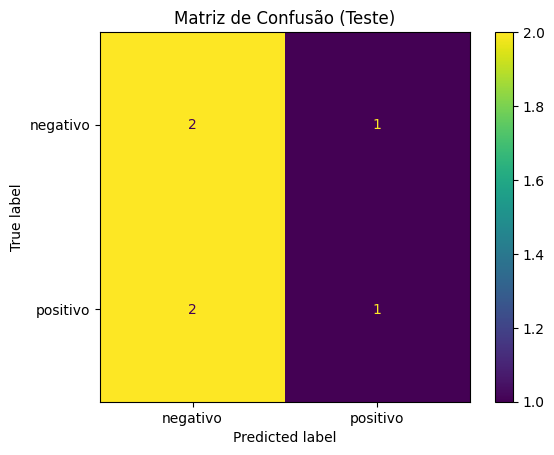

In [15]:
# importação das métricas
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["negativo(0)", "positivo(1)"]))

# A matriz de confusão mostra onde o modelo acerta e erra, explicitamente.
cm = confusion_matrix(y_test, y_pred, labels=[0,1])
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["negativo","positivo"]).plot()
plt.title("Matriz de Confusão (Teste)")
plt.show()

## Interpretação do relatório de classificação

O relatório acima resume o desempenho do modelo no **conjunto de teste**, que contém apenas **6 exemplos** (3 negativos e 3 positivos).  
Esse tamanho reduzido é importante, pois **cada erro impacta fortemente as métricas**.

### Classe negativa (0)

- **Recall = 0.67**  
  O modelo acertou **2 dos 3 exemplos negativos reais**.

- **Precision = 0.50**  
  Quando o modelo previu a classe *negativa*, apenas **metade das previsões estava correta**.

**Interpretação:**  
O modelo consegue identificar boa parte dos negativos, mas tende a **rotular exemplos positivos como negativos**, gerando falsos negativos.



### Classe positiva (1)

- **Recall = 0.33**  
  O modelo acertou **apenas 1 dos 3 exemplos positivos reais**.

- **Precision = 0.50**  
  Quando o modelo previu a classe *positiva*, acertou **1 em cada 2 vezes**.

**Interpretação:**  
O modelo tem dificuldade em identificar textos positivos e **perde a maioria deles**, classificando-os como negativos.


### Acurácia

- **Accuracy = 0.50**

Isso significa que o modelo acertou **3 de 6 exemplos**, desempenho equivalente a **uma escolha aleatória** nesse conjunto de teste.

⚠️ **Importante:**  
A acurácia, isoladamente, **não revela quais classes estão sendo mais prejudicadas**.  
Nesse caso, o relatório mostra claramente que a classe positiva é a mais afetada.


### Macro avg e Weighted avg

- **Macro average**  
  Média simples das métricas entre as classes, tratando positivo e negativo com a mesma importância.

- **Weighted average**  
  Média ponderada pelo número de exemplos de cada classe (*support*).

Como as classes estão balanceadas (3 exemplos cada), ambas as médias apresentam valores semelhantes.


### Leitura geral do resultado

Este relatório indica que:

- o modelo ainda **não generaliza bem**;
- há um viés em favor da classe negativa;
- o conjunto de teste é pequeno demais para conclusões robustas;
- métricas detalhadas são essenciais para entender o comportamento do classificador.

Esse resultado reforça a necessidade de:
- mais dados;
- melhor representação;
- e avaliação cuidadosa além da acurácia.


## 7. Interpretando a decisão do modelo (explicação local)

Até agora, avaliamos o modelo com métricas globais (acurácia, precisão, recall, F1).  
Nesta etapa, damos um passo adicional: **entender por que o modelo tomou uma decisão específica para uma frase concreta**.

Essa análise é chamada de **interpretação local**, pois explica uma previsão individual, e não o comportamento médio do modelo.

### Ideia central

A Regressão Logística é um modelo **linear**, o que significa que:

- cada *feature* (palavra ou bigrama) possui um **peso** aprendido durante o treinamento;
- a decisão final é resultado da **combinação linear** desses pesos com os valores TF-IDF da frase.

Em termos simples:

> algumas palavras empurram a decisão para o sentimento positivo,  
> outras empurram para o negativo.


### O que a função `prever_e_explicar` faz

Para uma frase fornecida, a função executa os seguintes passos:

1. **Transforma a frase em vetor TF-IDF**  
   Usando o mesmo vocabulário aprendido no treino.

2. **Calcula as probabilidades das classes**  
   Exibe `P(negativo)` e `P(positivo)` estimadas pelo modelo.

3. **Obtém a classe prevista**  
   Escolhe a classe com maior probabilidade.

4. **Calcula a contribuição de cada feature**  
   Multiplica:
   - o valor TF-IDF da feature na frase  
   - pelo coeficiente aprendido pelo modelo  

   Isso indica **quanto cada palavra contribuiu para a decisão final**.

5. **Exibe as principais contribuições**  
   Mostra apenas as *features* mais influentes presentes na frase.


### Como interpretar as contribuições

- **Contribuição positiva** → empurra a decisão para a classe positiva  
- **Contribuição negativa** → empurra a decisão para a classe negativa  
- Quanto maior o valor absoluto, **maior a influência** da palavra ou bigrama

Essa análise permite observar, por exemplo:
- palavras como *“excelente”* puxando fortemente para o positivo;
- expressões como *“ruim”* ou *“atendimento lento”* puxando para o negativo;
- o efeito combinado de múltiplos termos na decisão final.

### Limitações dessa explicação

É importante destacar que:
- essa interpretação é **aproximada**;
- ela funciona bem para **modelos lineares**;
- não captura fenômenos complexos como ironia ou pragmática.

Ainda assim, ela fornece uma **visão transparente e valiosa** do processo decisório do modelo.


### Objetivo pedagógico desta etapa

Esta célula tem como objetivo mostrar que:
- modelos de PLN **não são caixas-pretas impenetráveis**;
- é possível inspecionar e discutir decisões automaticamente;
- interpretar erros é tão importante quanto medir desempenho.

Esse tipo de análise prepara o terreno para discutir modelos mais complexos, nos quais a interpretabilidade se torna mais desafiadora.


In [16]:
def prever_e_explicar(frase, top_k=8):
    Xf = vectorizer.transform([frase])
    proba = clf.predict_proba(Xf)[0]
    pred = clf.predict(Xf)[0]
    print("Frase:", frase)
    print("P(neg)={:.3f} | P(pos)={:.3f} | pred={}".format(proba[0], proba[1], pred))

    feat = vectorizer.get_feature_names_out()
    coefs = clf.coef_[0]
    vec = Xf.toarray()[0]
    contrib = vec * coefs
    idx = np.argsort(np.abs(contrib))[::-1][:top_k]

    print("Top contribuições:")
    for i in idx:
        if vec[i] > 0:
            print(f"  {feat[i]:25s} contrib={contrib[i]: .4f}")
    print("-"*60)

prever_e_explicar("O produto é excelente")
prever_e_explicar("O produto é ruim")
prever_e_explicar("Atendimento lento e ruim")

Frase: O produto é excelente
P(neg)=0.404 | P(pos)=0.596 | pred=1
Top contribuições:
  excelente                 contrib= 0.2301
  produto excelente         contrib= 0.1878
  produto                   contrib=-0.0384
------------------------------------------------------------
Frase: O produto é ruim
P(neg)=0.623 | P(pos)=0.377 | pred=0
Top contribuições:
  ruim                      contrib=-0.2841
  produto ruim              contrib=-0.1891
  produto                   contrib=-0.0399
------------------------------------------------------------
Frase: Atendimento lento e ruim
P(neg)=0.566 | P(pos)=0.434 | pred=0
Top contribuições:
  ruim                      contrib=-0.3686
  atendimento               contrib= 0.0948
------------------------------------------------------------


## 8. Discussão

- Por que TF-IDF + Regressão Logística tende a melhorar o resultado?
- O que bigramas capturam (ex.: "não gostei")?
- Quais limitações persistem (ironia, contexto, pragmática)?

### Respostas às Perguntas

**1. Por que TF-IDF + Regressão Logística tende a melhorar o resultado?**

- **TF-IDF (Term Frequency-Inverse Document Frequency):** Em vez de simplesmente contar a frequência das palavras (como no Bag-of-Words), o TF-IDF atribui pesos às palavras com base em sua importância tanto no documento atual quanto em todo o corpus. Palavras comuns que aparecem em muitos documentos (como 'o', 'a', 'é') recebem pesos menores, enquanto palavras mais específicas que distinguem um documento de outros recebem pesos maiores. Isso ajuda a focar em termos mais discriminativos para a classificação.

- **Regressão Logística:** É um modelo linear robusto e eficiente para tarefas de classificação binária (como positivo/negativo). Ele modela a probabilidade de uma determinada classe e é bom em capturar relações lineares entre as características (os pesos TF-IDF das palavras) e o rótulo da classe. Em comparação com Naive Bayes, que assume independência entre as características (o que raramente é verdade na linguagem natural), a Regressão Logística pode aprender a importância relativa de diferentes características de forma mais sofisticada, muitas vezes resultando em melhor desempenho em tarefas de análise de sentimento quando as características são bem representadas.

**2. O que bigramas capturam (ex.: 'não gostei')?**

Bigramas são sequências de duas palavras consecutivas. Ao incluir bigramas na vetorização (juntamente com unigramas, que são palavras únicas), o modelo consegue capturar o contexto e a ordem das palavras, o que é crucial para expressar sentimentos e negações.

Por exemplo:
- A frase "não gostei" é um bigrama que claramente indica sentimento negativo.
- Se o modelo considerasse apenas unigramas ('não' e 'gostei'), ele poderia interpretar 'gostei' como positivo e 'não' como um modificador, mas a combinação "não gostei" como uma única característica ('feature') captura a negação de forma mais eficaz e precisa. Isso é especialmente útil para frases como "muito bom", "pouco satisfeito", que alteram o significado de palavras individuais.

**3. Quais limitações persistem (ironia, contexto, pragmática)?**

Mesmo com melhorias como TF-IDF e bigramas, modelos baseados apenas em características de palavras ainda enfrentam várias limitações:

-   **Ironia e Sarcasmo:** Frases como "Que ótimo, choveu o dia todo!" seriam provavelmente classificadas como positivas devido à palavra 'ótimo', mesmo que o sentido seja negativo. O modelo não consegue entender a intenção por trás da expressão. Sem um entendimento mais profundo do mundo e do contexto da conversa, ironia e sarcasmo são extremamente difíceis de detectar.

-   **Contexto e Ambiguidade Semântica:** Palavras podem ter significados diferentes dependendo do contexto. Por exemplo, "Não é bom" é negativo, mas "Não, é bom!" é positivo. Um modelo simples de TF-IDF pode ter dificuldade em distinguir nuances sutis de pontuação ou inflexão. Além disso, o significado de uma palavra pode mudar drasticamente com o domínio (e.g., 'bug' em computação vs. 'bug' em um quarto).

-   **Pragmática:** A pragmática lida com o significado implícito da linguagem, ou seja, o que as pessoas querem dizer além do que as palavras literalmente expressam. Modelos baseados em palavras e bigramas não conseguem inferir intenções ou pressuposições complexas que são parte integrante da comunicação humana. Para isso, seriam necessários modelos muito mais avançados que compreendam o mundo e o comportamento humano, como os Large Language Models (LLMs).